## Импорты

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, ifft
from scipy.signal import fftconvolve
import scipy.signal as sig
import scipy
from scipy.io import wavfile
import requests
from io import BytesIO
from scipy.fft import fft, ifft, next_fast_len 
from scipy.io.wavfile import write as wav_write
import scipy.fftpack


%matplotlib inline

## Пункт 1

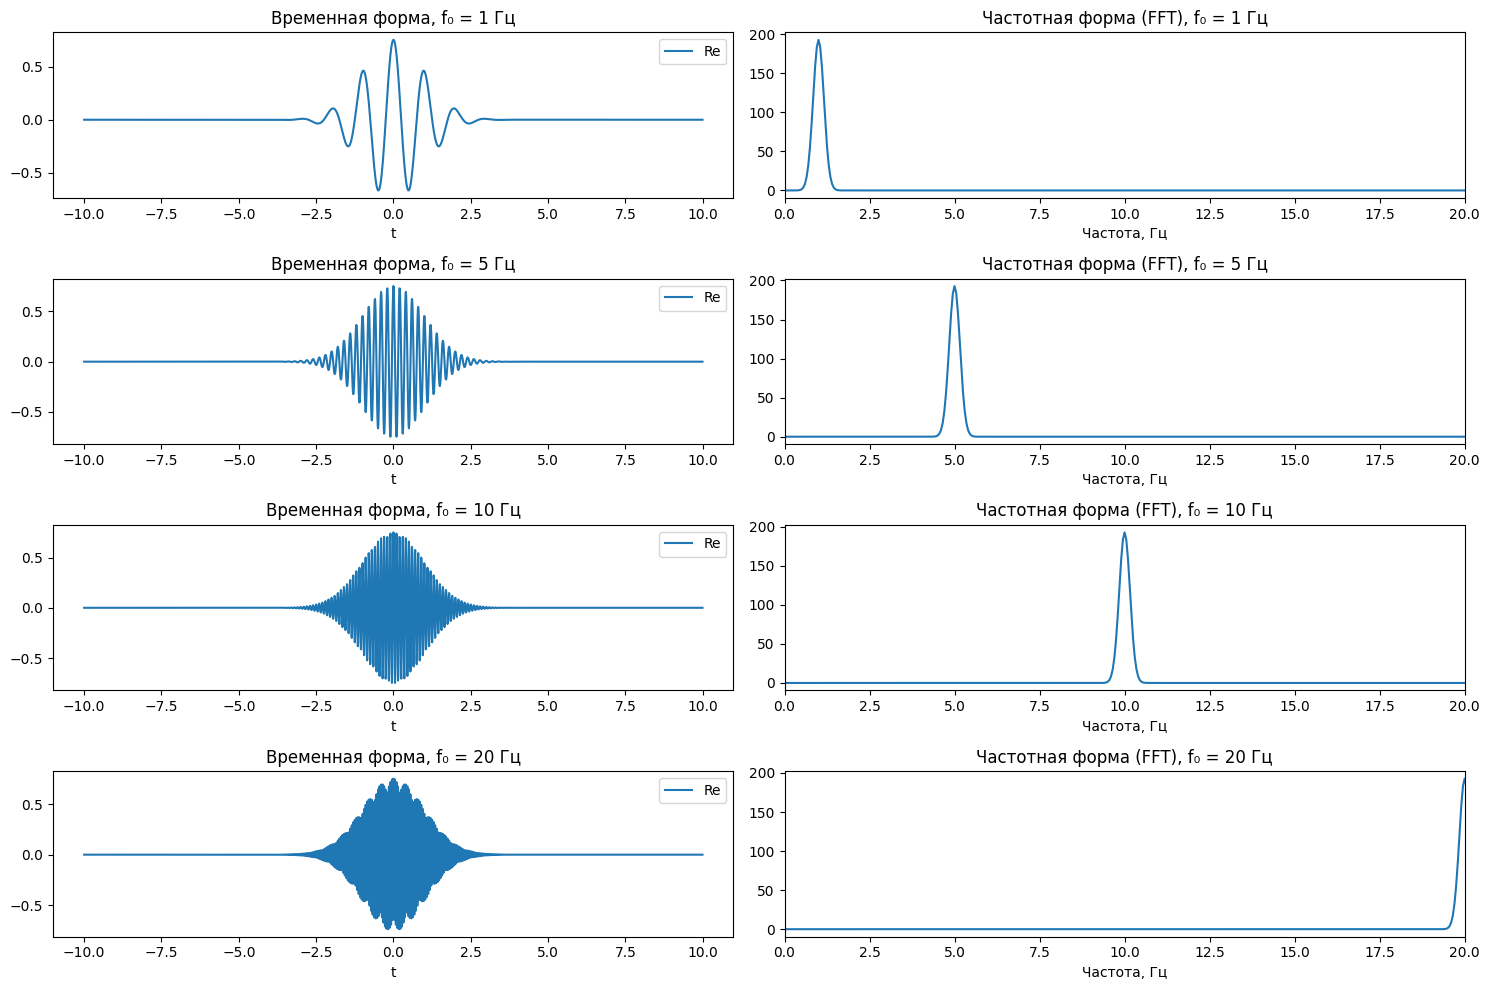

In [14]:
t = np.linspace(-10, 10, 2048, endpoint=False)
dt = t[1] - t[0]

def morlet_time(t, f0=5.0, sigma=1.0):
    
    norm = np.pi**(-0.25) / np.sqrt(sigma)
    gaussian = np.exp(-t**2 / (2 * sigma**2))
    complex_exp = np.exp(1j * 2 * np.pi * f0 * t)
    return norm * gaussian * complex_exp


f0_values = [1, 5, 10, 20]

fig, axs = plt.subplots(len(f0_values), 2, figsize=(15, 10)) #3
for i, f0 in enumerate(f0_values):
    psi = morlet_time(t, f0=f0, sigma=1.0)
    
    # Временная форма 
    axs[i, 0].plot(t, np.real(psi), label='Re')
    # axs[i, 0].plot(t, np.imag(psi), label='Im')
    # axs[i, 0].plot(t, np.abs(psi), '--', label='|ψ|')
    axs[i, 0].set_title(f'Временная форма, f₀ = {f0} Гц')
    axs[i, 0].set_xlabel('t')
    axs[i, 0].legend()
    
    # Частотная форма 
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма (FFT), f₀ = {f0} Гц')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Теоретическая частотная форма 
    # gauss_freq = np.exp(-(freq - f0)**2 / 2)
    # axs[i, 2].plot(freq[idx], gauss_freq[idx], label='Теор. (сдвиг)')
    # axs[i, 2].set_title('Теоретическая частотная форма')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 2

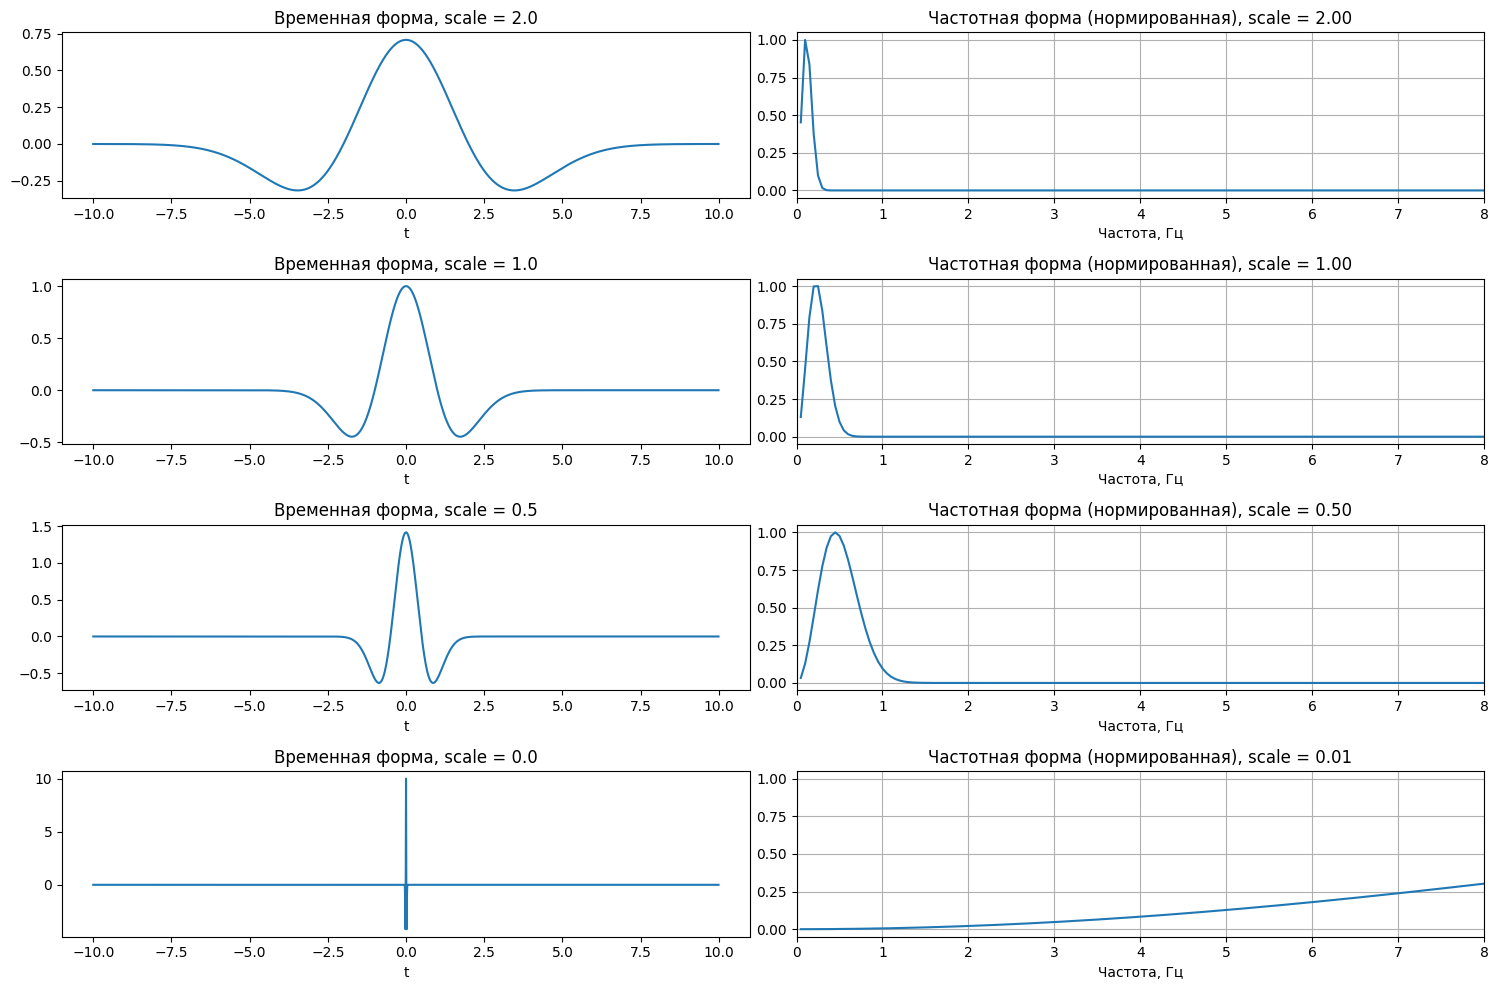

In [22]:
def mexican_hat_time(t, scale=1.0):
    
    t_scaled = t / scale
    psi = (2 / (np.sqrt(3 * np.pi**0.25))) * (1 - t_scaled**2) * np.exp(-t_scaled**2 / 2)
    return psi / np.sqrt(scale)  


scales = [2.0, 1.0, 0.5, 0.01]  

fig, axs = plt.subplots(len(scales), 2, figsize=(15, 10)) #3
for i, sc in enumerate(scales):
    psi = mexican_hat_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма, scale = {sc:.1f}')
    axs[i, 0].set_xlabel('t')
    
    # Частотная форма
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    # Нормируем амплитуду спектра для удобства сравнения (по максимуму)
    spectrum = np.abs(psi_fft[idx])
    spectrum = spectrum / np.max(spectrum)   # нормируем каждый спектр к 1
    
    axs[i, 1].plot(freq[idx], spectrum)
    axs[i, 1].set_title(f'Частотная форма (нормированная), scale = {sc:.2f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 8)
    axs[i, 1].grid(True)
    # Теоретический пик частоты 
    # f_peak = 0.8 / sc
    # axs[i, 2].axvline(f_peak, color='r', linestyle='--', label=f'Пик ≈ {f_peak:.1f} Гц')
    # axs[i, 2].set_title('Сдвиг центральной частоты')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 3

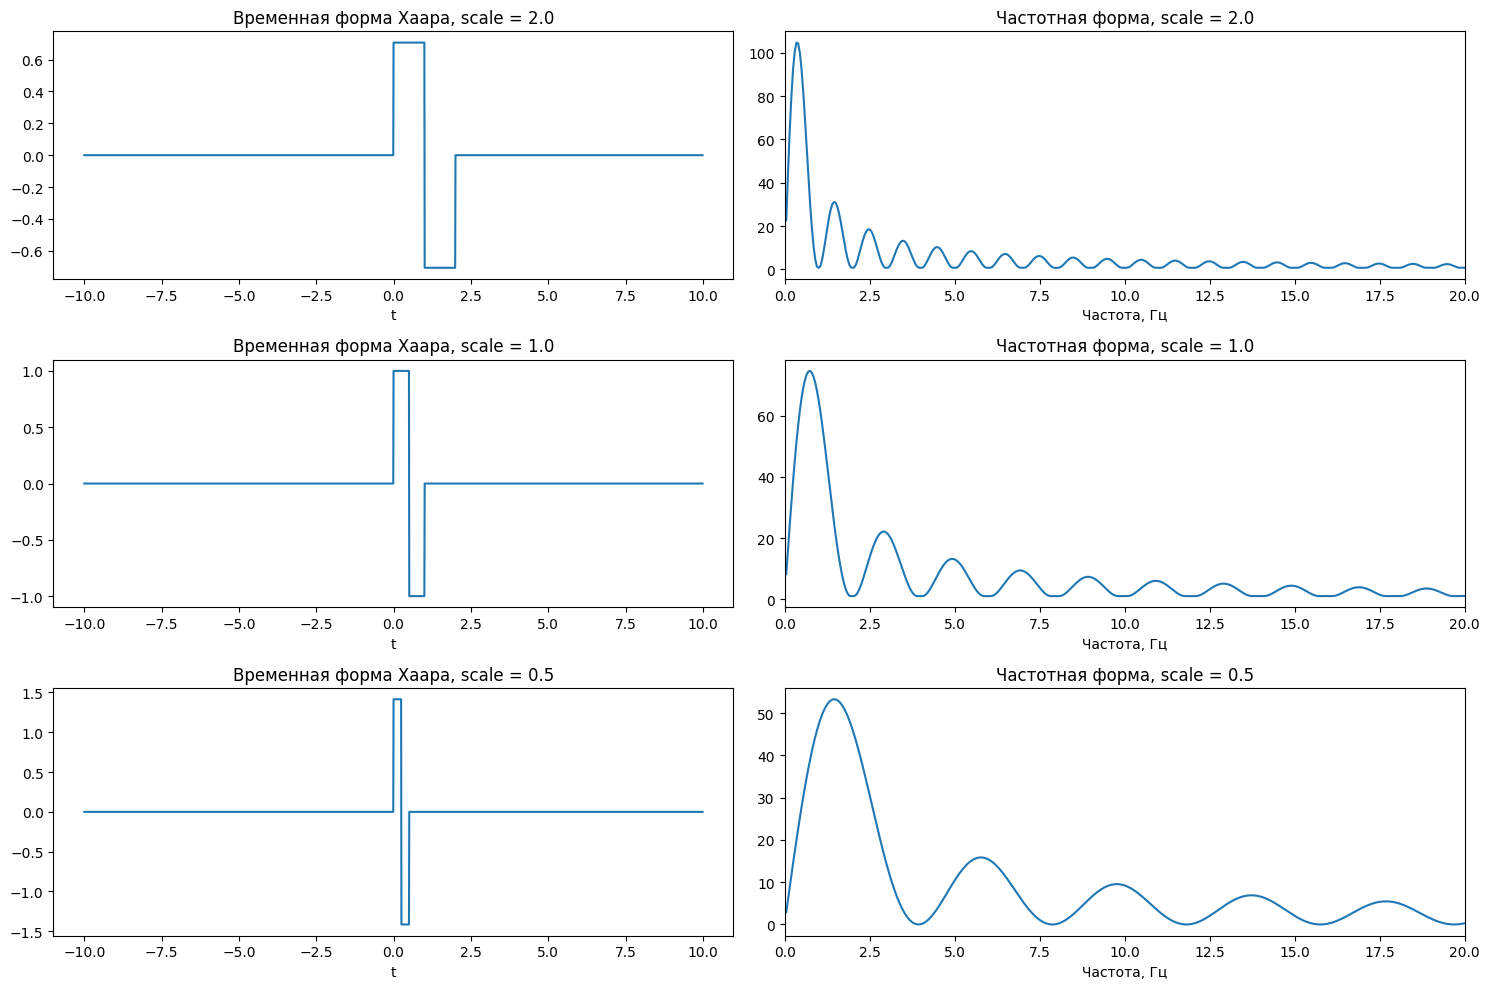

In [23]:
def haar_time(t, scale=1.0):
    
    psi = np.zeros_like(t)
    mask1 = (t >= 0) & (t < 0.5 * scale)
    mask2 = (t >= 0.5 * scale) & (t < 1.0 * scale)
    psi[mask1] = 1.0
    psi[mask2] = -1.0
    return psi / np.sqrt(scale)  

scales_haar = [2.0, 1.0, 0.5]

fig, axs = plt.subplots(len(scales_haar), 2, figsize=(15, 10)) #3
for i, sc in enumerate(scales_haar):
    psi = haar_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма Хаара, scale = {sc:.1f}')
    axs[i, 0].set_xlabel('t')
    
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма, scale = {sc:.1f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Центральная частота 
    # f_c = 0.5 / sc
    # axs[i, 2].axvline(f_c, color='r', linestyle='--', label=f'Центр ≈ {f_c:.1f} Гц')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 4

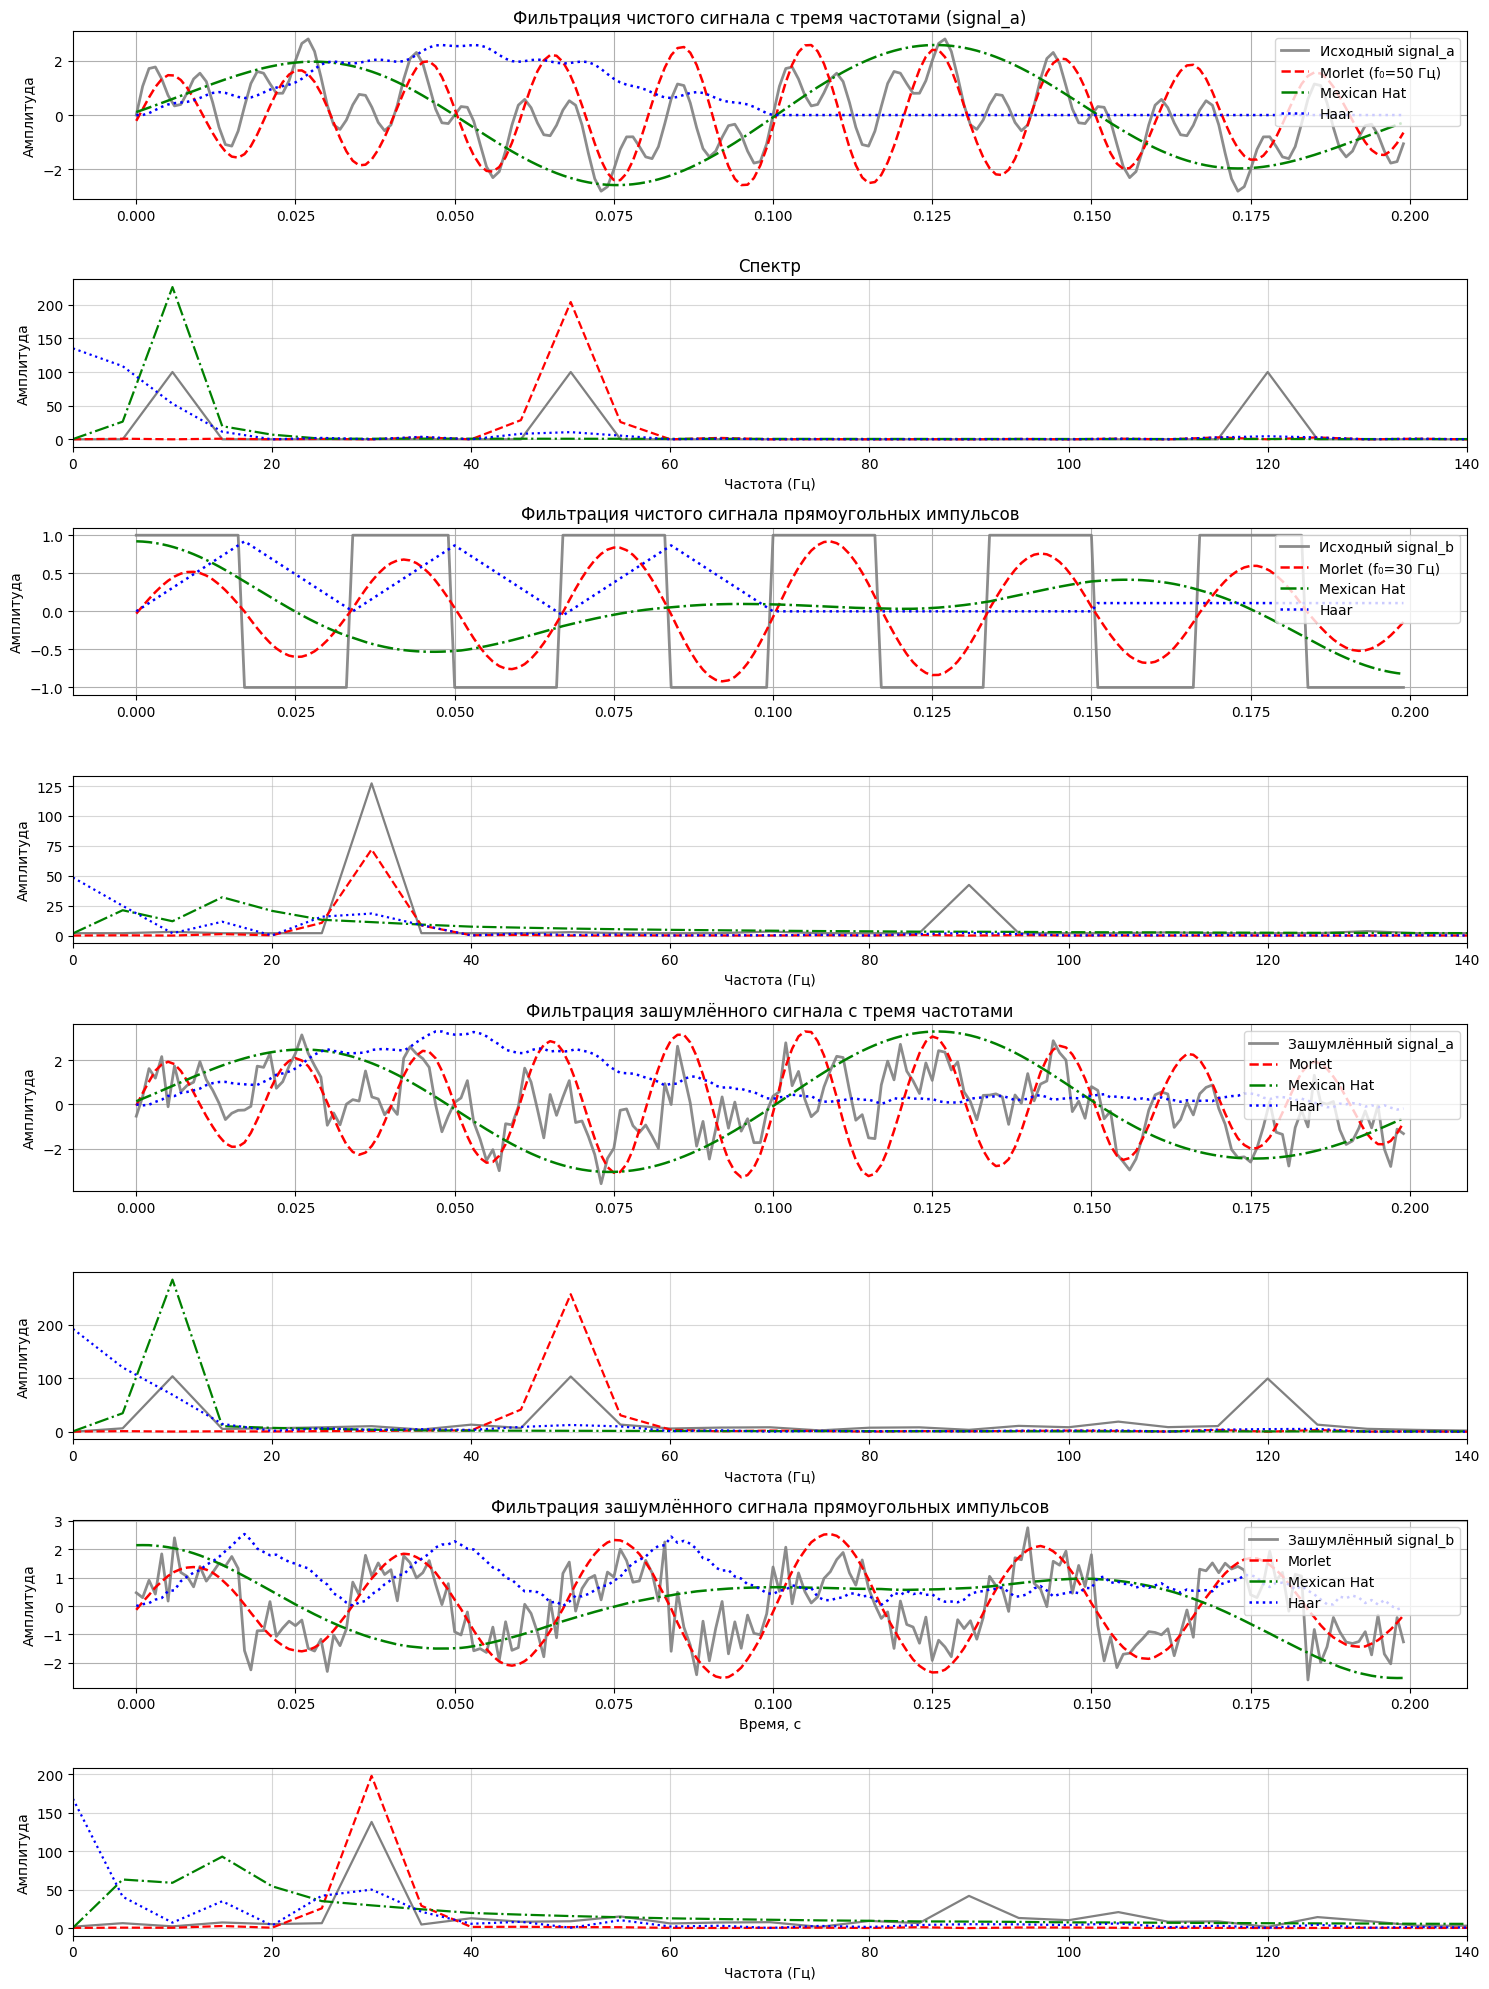

In [69]:
fs = 1000
t_sig = np.arange(0, 0.2, 1/fs)

signal_a = (np.sin(2*np.pi*10*t_sig) + 
            np.sin(2*np.pi*50*t_sig) + 
            np.sin(2*np.pi*120*t_sig))

signal_b = sig.square(2*np.pi*30*t_sig)

noise = 0.6 * np.random.randn(len(t_sig))
signal_a_noisy = signal_a + noise
signal_b_noisy = signal_b + noise

def wavelet_convolve(signal_data, wavelet_func, param, is_morlet=False):
    t_wave = t_sig - t_sig.mean()
    wav = wavelet_func(t_wave, param)
    
    if is_morlet:
        wav = np.real(wav)
    
    conv_result = sig.convolve(signal_data, wav, mode='same')
    
    orig_max = np.max(np.abs(signal_data))
    conv_max = np.max(np.abs(conv_result))
    
    if conv_max > 0:
        scaling_factor = orig_max / conv_max * 0.92   
        conv_result *= scaling_factor
    
    return conv_result


conv_mor_a  = wavelet_convolve(signal_a, morlet_time, 50, is_morlet=True)
conv_mex_a  = wavelet_convolve(signal_a, mexican_hat_time, 0.018)
conv_haar_a = wavelet_convolve(signal_a, haar_time, 0.38)

conv_mor_b  = wavelet_convolve(signal_b, morlet_time, 30, is_morlet=True)
conv_mex_b  = wavelet_convolve(signal_b, mexican_hat_time, 0.028)
conv_haar_b = wavelet_convolve(signal_b, haar_time, 0.55)

conv_mor_a_noisy  = wavelet_convolve(signal_a_noisy, morlet_time, 50, is_morlet=True)
conv_mex_a_noisy  = wavelet_convolve(signal_a_noisy, mexican_hat_time, 0.018)
conv_haar_a_noisy = wavelet_convolve(signal_a_noisy, haar_time, 0.38)

conv_mor_b_noisy  = wavelet_convolve(signal_b_noisy, morlet_time, 30, is_morlet=True)
conv_mex_b_noisy  = wavelet_convolve(signal_b_noisy, mexican_hat_time, 0.028)
conv_haar_b_noisy = wavelet_convolve(signal_b_noisy, haar_time, 0.55)


fig, axs = plt.subplots(8, 1, figsize=(15, 20))


def plot_spectrum(ax, signal, label, color, linestyle='-'):
    N = len(signal)
    spectrum = np.abs(fft(signal)[:N//2])
    freq = fftfreq(N, 1/fs)[:N//2]
    ax.plot(freq, spectrum, color=color, linestyle=linestyle, linewidth=1.6, label=label)
    ax.set_xlim(0, 140)
    ax.set_xlabel('Частота (Гц)')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.5)

# 1. Чистый signal_a
axs[0].plot(t_sig, signal_a,      'gray', alpha=0.9, linewidth=2.0, label='Исходный signal_a')
axs[0].plot(t_sig, conv_mor_a,   'red',   linewidth=1.8, label='Morlet (f₀=50 Гц)', linestyle='--')
axs[0].plot(t_sig, conv_mex_a,   'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[0].plot(t_sig, conv_haar_a,  'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[0].set_title('Фильтрация чистого сигнала с тремя частотами (signal_a)')
axs[0].set_ylabel('Амплитуда')
axs[0].legend(loc='upper right')
axs[0].grid(True)

plot_spectrum(axs[1], signal_a,      'Исходный', 'gray')
plot_spectrum(axs[1], conv_mor_a,   'Morlet', 'red', '--')
plot_spectrum(axs[1], conv_mex_a,   'Mexican Hat', 'green', '-.')
plot_spectrum(axs[1], conv_haar_a,  'Haar', 'blue', 'dotted')
axs[1].set_title('Спектр')

# 2. Чистый signal_b
axs[2].plot(t_sig, signal_b,      'gray', alpha=0.9, linewidth=2.0, label='Исходный signal_b')
axs[2].plot(t_sig, conv_mor_b,   'red',   linewidth=1.8, label='Morlet (f₀=30 Гц)', linestyle='--')
axs[2].plot(t_sig, conv_mex_b,   'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[2].plot(t_sig, conv_haar_b,  'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[2].set_title('Фильтрация чистого сигнала прямоугольных импульсов')
axs[2].set_ylabel('Амплитуда')
axs[2].legend(loc='upper right')
axs[2].grid(True)

plot_spectrum(axs[3], signal_b,      'Исходный', 'gray')
plot_spectrum(axs[3], conv_mor_b,   'Morlet', 'red', '--')
plot_spectrum(axs[3], conv_mex_b,   'Mexican Hat', 'green', '-.')
plot_spectrum(axs[3], conv_haar_b,  'Haar', 'blue', 'dotted')

# 3. Зашумлённый signal_a
axs[4].plot(t_sig, signal_a_noisy, 'gray', alpha=0.9, linewidth=2.0, label='Зашумлённый signal_a')
axs[4].plot(t_sig, conv_mor_a_noisy,  'red',   linewidth=1.8, label='Morlet', linestyle='--')
axs[4].plot(t_sig, conv_mex_a_noisy,  'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[4].plot(t_sig, conv_haar_a_noisy, 'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[4].set_title('Фильтрация зашумлённого сигнала с тремя частотами')
axs[4].set_ylabel('Амплитуда')
axs[4].legend(loc='upper right')
axs[4].grid(True)

plot_spectrum(axs[5], signal_a_noisy, 'Исходный', 'gray')
plot_spectrum(axs[5], conv_mor_a_noisy, 'Morlet', 'red', '--')
plot_spectrum(axs[5], conv_mex_a_noisy, 'Mexican Hat', 'green', '-.')
plot_spectrum(axs[5], conv_haar_a_noisy, 'Haar', 'blue', 'dotted')

# 4. Зашумлённый signal_b
axs[6].plot(t_sig, signal_b_noisy, 'gray', alpha=0.9, linewidth=2.0, label='Зашумлённый signal_b')
axs[6].plot(t_sig, conv_mor_b_noisy,  'red',   linewidth=1.8, label='Morlet', linestyle='--')
axs[6].plot(t_sig, conv_mex_b_noisy,  'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[6].plot(t_sig, conv_haar_b_noisy, 'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[6].set_title('Фильтрация зашумлённого сигнала прямоугольных импульсов')
axs[6].set_xlabel('Время, с')
axs[6].set_ylabel('Амплитуда')
axs[6].legend(loc='upper right')
axs[6].grid(True)

plot_spectrum(axs[7], signal_b_noisy, 'Исходный', 'gray')
plot_spectrum(axs[7], conv_mor_b_noisy, 'Morlet', 'red', '--')
plot_spectrum(axs[7], conv_mex_b_noisy, 'Mexican Hat', 'green', '-.')
plot_spectrum(axs[7], conv_haar_b_noisy, 'Haar', 'blue', 'dotted')

plt.tight_layout()
plt.show()

## Пункт 5

Нормы вейвлетов: min=0.0568, max=0.2539, mean=0.1759
=== ДЕБАГ: АМПЛИТУДА ВЕЙВЛЕТОВ (np.abs) ДЛЯ t < 0 ===
Частота 5.0 Гц | max amp (t<0): 0.0046 | mean amp (t<0): 0.0003 | min amp (t<0): 0.000000
Частота 53.1 Гц | max amp (t<0): 0.0484 | mean amp (t<0): 0.0003 | min amp (t<0): 0.000000
Частота 100.0 Гц | max amp (t<0): 0.0912 | mean amp (t<0): 0.0004 | min amp (t<0): 0.000000

=== ДЕБАГ: МОЩНОСТЬ tf ДЛЯ t < 0 ===
Форма left_tf: (80, 1501)
Макс. мощность (t<0)   : 0.25
Средняя мощность (t<0) : 0.02
Мин. мощность (t<0)    : 0.00
Мощность на t≈-2.99 (самый левый край) : 0.06
Мощность на t≈-0.01 (прямо перед 0)   : 0.25


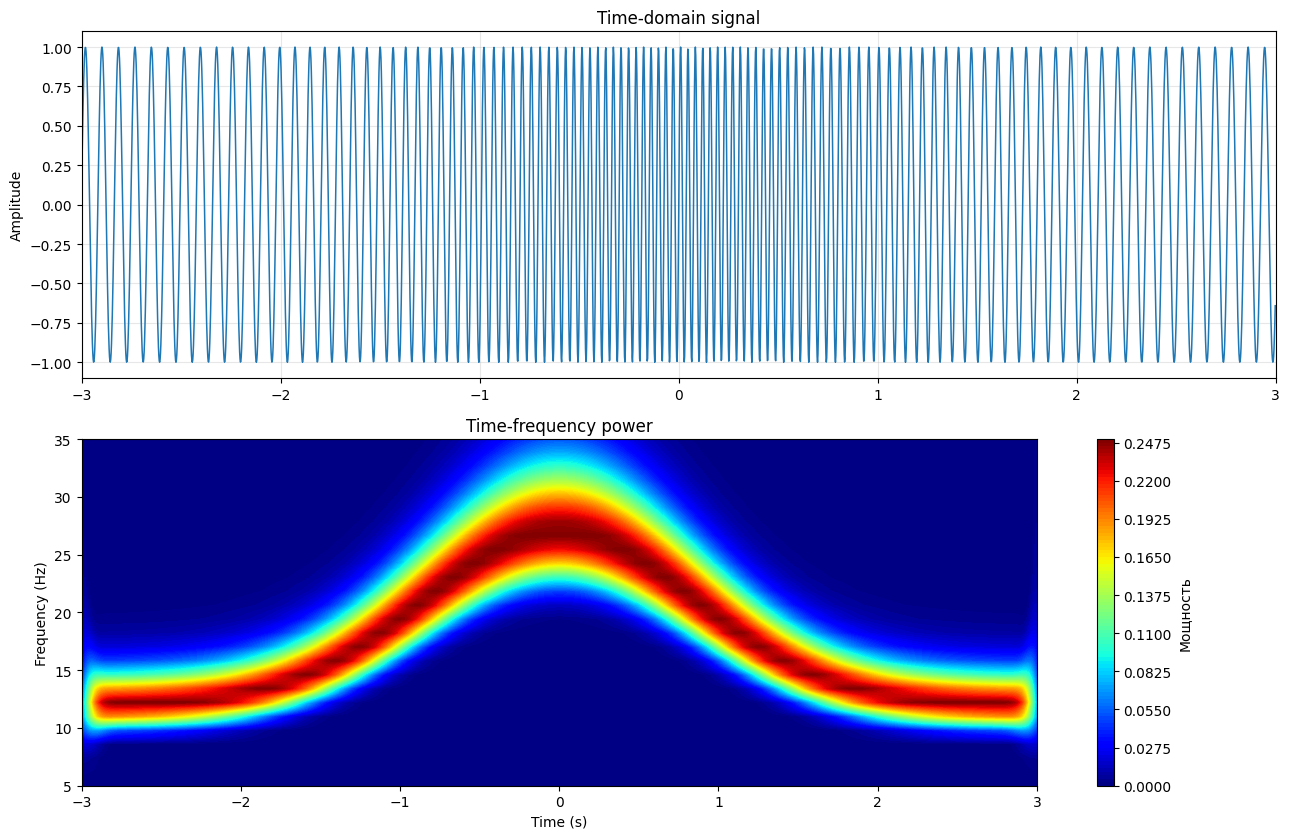

In [23]:
srate = 500
time = np.arange(-3, 3, 1/srate)
n = len(time)


freqmod = 11 + 15 * np.exp(-(time / 1.2)**2)

phase = time + np.cumsum(freqmod) / srate
signal = np.sin(2 * np.pi * phase)

frex = np.linspace(5, 100, 80)


wavelets = np.zeros((len(frex), n), dtype=complex)
cycles = 5.5          

for wi in range(len(frex)):
    
    sigma = cycles / (2 * np.pi * frex[wi])      
    # sigma = cycles / frex[wi]                  
    gaussian = np.exp(-time**2 / (2 * sigma**2))
    norm_factor = np.sum(gaussian)
    wavelets[wi, :] = np.exp(1j * 2 * np.pi * frex[wi] * time) * gaussian / norm_factor

norms = np.array([np.sqrt(np.sum(np.abs(wavelets[wi, :])**2)) for wi in range(len(frex))])
print(f"Нормы вейвлетов: min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}")


print("=== ДЕБАГ: АМПЛИТУДА ВЕЙВЛЕТОВ (np.abs) ДЛЯ t < 0 ===")
left_mask = time < 0
for idx in [0, len(frex)//2, -1]:               
    amp_left = np.abs(wavelets[idx, left_mask])
    print(f"Частота {frex[idx]:.1f} Гц | "
          f"max amp (t<0): {np.max(amp_left):.4f} | "
          f"mean amp (t<0): {np.mean(amp_left):.4f} | "
          f"min amp (t<0): {np.min(amp_left):.6f}")


nconv = n * 2 - 1
sigX = scipy.fftpack.fft(signal, nconv)
tf = np.zeros((len(frex), n))

tf_plot = np.log10(tf + 1e-10)

for fi in range(len(frex)):
    waveX = scipy.fftpack.fft(wavelets[fi, :], nconv)
    convres = scipy.fftpack.ifft(waveX * sigX)
    
    start = nconv//2 - n//2
    tf[fi, :] = np.abs(convres[start : start + n])**2

print("\n=== ДЕБАГ: МОЩНОСТЬ tf ДЛЯ t < 0 ===")
left_tf = tf[:, left_mask]
print(f"Форма left_tf: {left_tf.shape}")
print(f"Макс. мощность (t<0)   : {np.max(left_tf):.2f}")
print(f"Средняя мощность (t<0) : {np.mean(left_tf):.2f}")
print(f"Мин. мощность (t<0)    : {np.min(left_tf):.2f}")

print(f"Мощность на t≈-2.99 (самый левый край) : {np.max(left_tf[:, 0]):.2f}")
print(f"Мощность на t≈-0.01 (прямо перед 0)   : {np.max(left_tf[:, -1]):.2f}")

fig, axs = plt.subplots(2, 1, figsize=(13, 8.5))

axs[0].plot(time, signal, color='#1f77b4', linewidth=1.1)
axs[0].set_title('Time-domain signal')
axs[0].set_ylabel('Amplitude')
axs[0].set_xlim(-3, 3)
axs[0].grid(True, alpha=0.3)

im = axs[1].contourf(time, frex, tf, levels=120, cmap='jet')
axs[1].set_title('Time-frequency power')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Frequency (Hz)')
axs[1].set_xlim(-3, 3)
axs[1].set_ylim(5, 35)
fig.colorbar(im, ax=axs[1], label='Мощность')

plt.tight_layout()
plt.show()

## Пункт 6

Скачано аудио: 5.0 сек, fs = 16000 Гц
=== ЧИСТАЯ НОТА 440 Гц ===


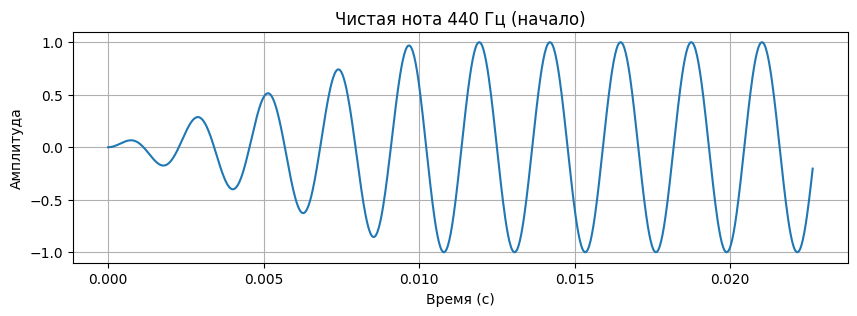

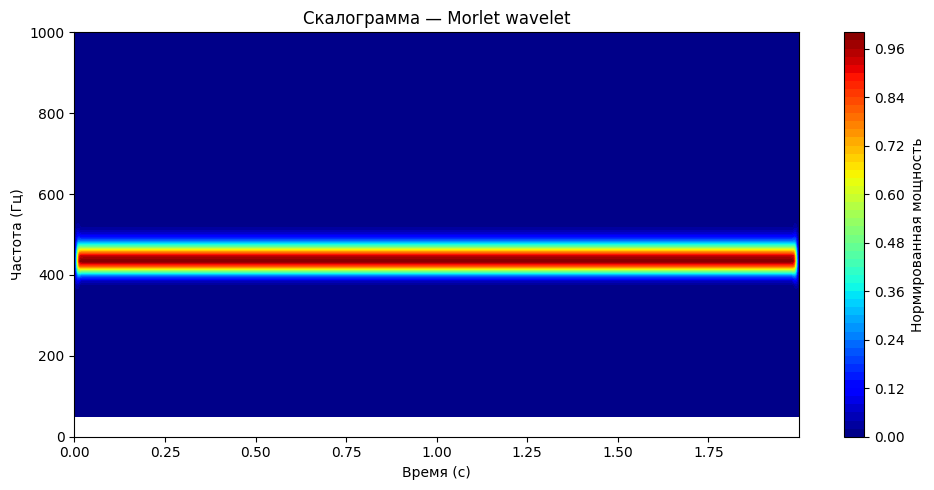

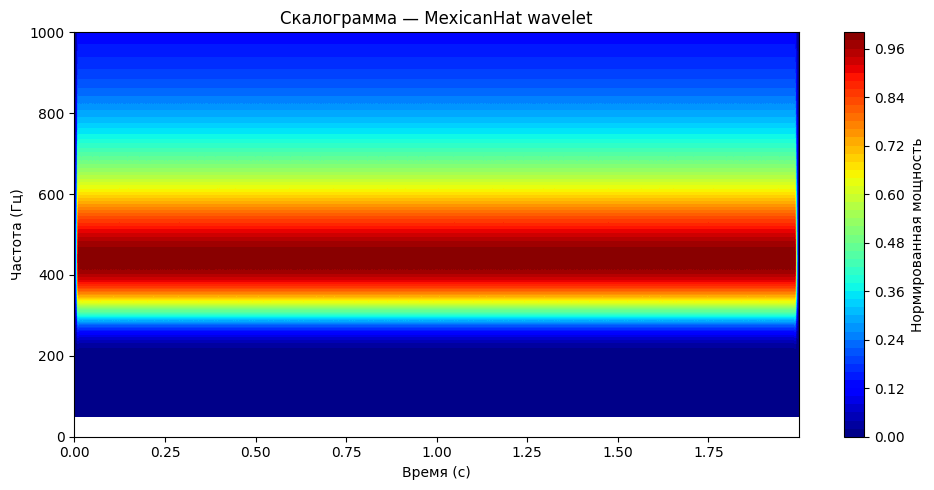

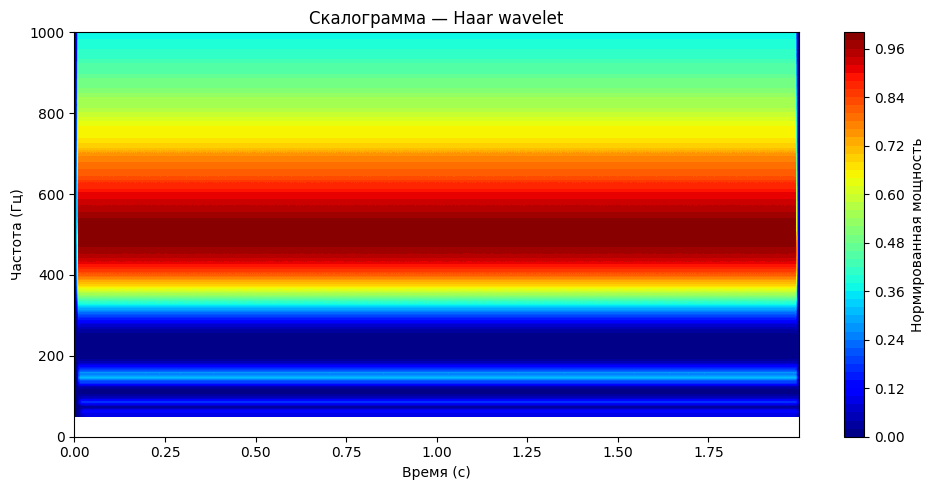

=== СКАЧАННОЕ АУДИО ===


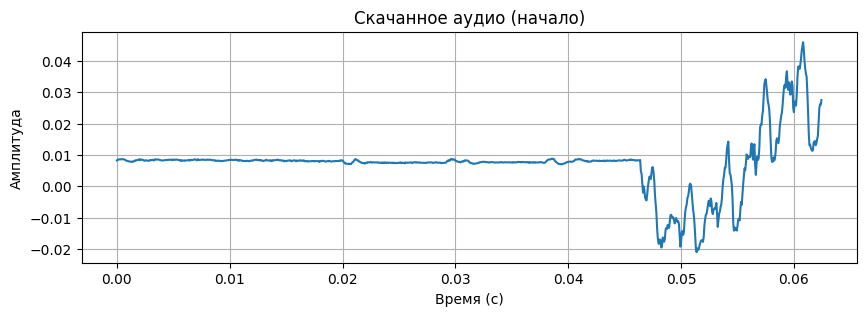

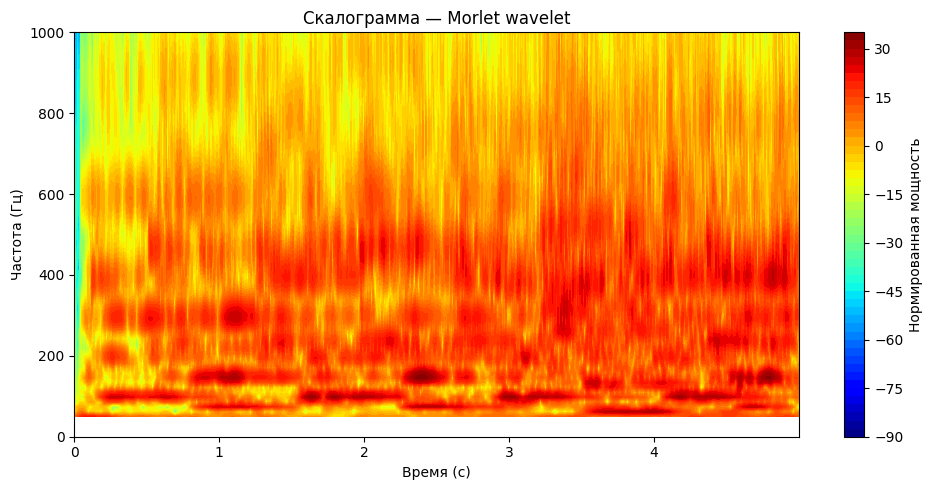

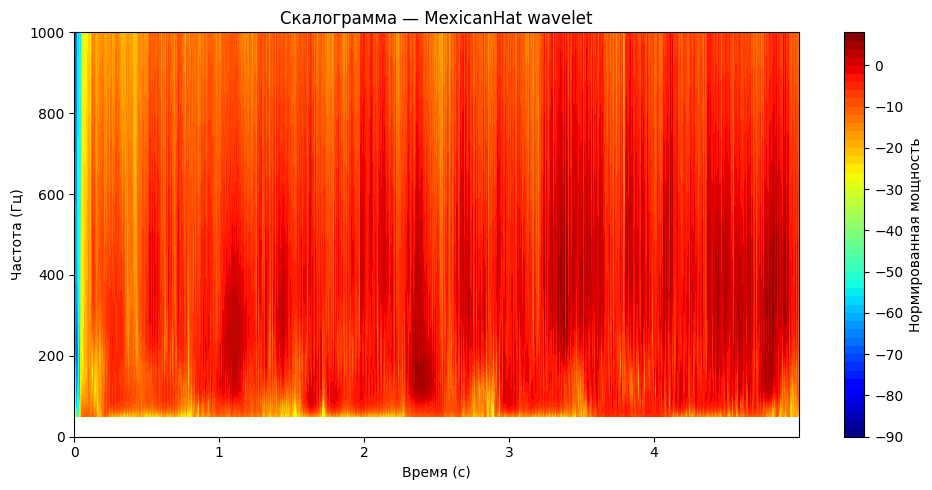

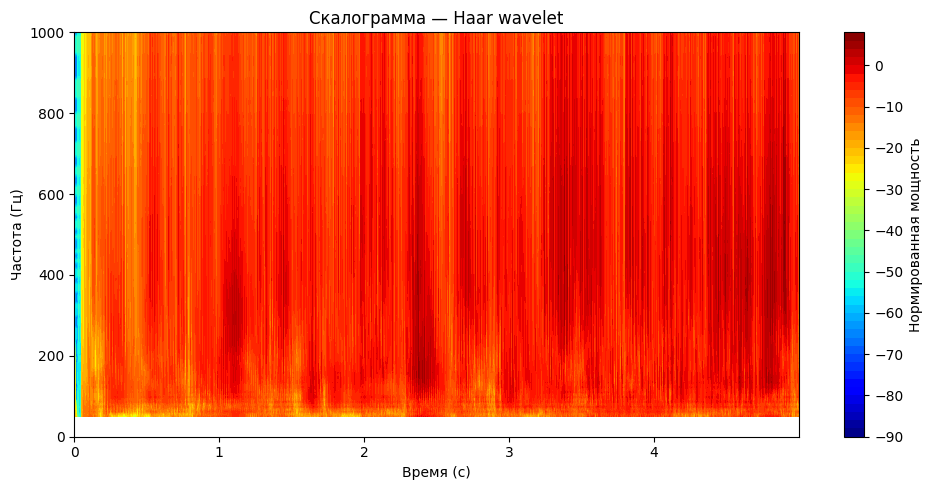


Готово! Файлы сохранены.


In [34]:


# "ля"
fs = 44100
dur = 2.0
t = np.arange(0, dur, 1/fs)

fade = 0.01  # секунды
fade_samples = int(fade * fs)
window = np.ones(len(t))
window[:fade_samples] = np.linspace(0, 1, fade_samples)
window[-fade_samples:] = np.linspace(1, 0, fade_samples)

pure_note = window * np.sin(2 * np.pi * 440 * t)

url = "https://github.com/rafaelreis-hotmart/Audio-Sample-files/raw/master/sample.wav"
response = requests.get(url, timeout=10)
fs_any, data = wavfile.read(BytesIO(response.content))

if len(data.shape) > 1:
    data = np.mean(data, axis=1)
data = data.astype(np.float64)
data /= np.max(np.abs(data)) + 1e-8

any_audio = data[:int(fs_any * 5)]

print(f"Скачано аудио: {len(any_audio)/fs_any:.1f} сек, fs = {fs_any} Гц")

# Вейвлеты
def mexican_hat_time(t_samples, scale):
    t_norm = t_samples / scale
    psi = (1 - t_norm**2) * np.exp(-0.5 * t_norm**2)
    norm_const = 2 / (np.sqrt(3) * np.pi**0.25)   
    return norm_const * psi / np.sqrt(scale)      

def haar_time(t_samples, scale):
    t_norm = t_samples / scale
    wave = np.zeros_like(t_samples, dtype=float)
    wave[(t_norm >= 0) & (t_norm < 0.5)] = 1.0
    wave[(t_norm >= 0.5) & (t_norm < 1.0)] = -1.0
    return wave / np.sqrt(scale)

# Функция скалограммы 
def build_spectrogram(signal, fs, wavelet_name="Morlet", n_frex=80, max_freq=1000, custom = False):
    n = len(signal)
    time = np.arange(n) / fs
    frex = np.linspace(50, max_freq, n_frex)
    
    t_centered = (np.arange(n) - n//2) / fs          
    t_samples = t_centered * fs
    
    tf = np.zeros((len(frex), n))
    
    
    nconv = n * 2 - 1
    nconv_fast = next_fast_len(nconv) 
    sigX = fft(signal, nconv_fast)
    
    for fi, f in enumerate(frex):
        if wavelet_name == "Morlet":
            sigma_sec = 2.0 / f                      
            g = np.exp(-t_centered**2 / (2 * sigma_sec**2))
            wave = np.exp(1j * 2 * np.pi * f * t_centered) * g
        elif wavelet_name == "MexicanHat":
            scale = 0.2516 * fs / f                 
            wave = mexican_hat_time(t_samples, scale)
        elif wavelet_name == "Haar":
            scale = fs / f                           
            wave = haar_time(t_samples, scale)
        
        waveX = fft(wave, nconv_fast)
        convres = ifft(waveX * sigX)
        
        
        half_wave = n // 2
        tf[fi, :] = np.abs(convres[half_wave : half_wave + n]) ** 2
    
    
    if not custom:
        tf = tf / np.max(tf)
    else:
        tf = 10 * np.log10(tf + 1e-9)
    
    plt.figure(figsize=(10, 5))
    plt.contourf(time, frex, tf, levels=60, cmap='jet')
    plt.colorbar(label='Нормированная мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title(f'Скалограмма — {wavelet_name} wavelet')
    plt.ylim(0, max_freq)
    plt.tight_layout()
    plt.show()


def plot_waveform(signal, fs, title):
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(signal[:1000]))/fs, signal[:1000])
    plt.title(title)
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.show()

print("=== ЧИСТАЯ НОТА 440 Гц ===")
plot_waveform(pure_note, fs, "Чистая нота 440 Гц (начало)")
build_spectrogram(pure_note, fs, "Morlet", custom=False)
build_spectrogram(pure_note, fs, "MexicanHat", custom=False)
build_spectrogram(pure_note, fs, "Haar", custom=False)

print("=== СКАЧАННОЕ АУДИО ===")
plot_waveform(any_audio, fs_any, "Скачанное аудио (начало)")

build_spectrogram(any_audio, fs_any, "Morlet", max_freq=1000, custom=True) # переключить на false для линейного нормирования, true - для логарифмического
build_spectrogram(any_audio, fs_any, "MexicanHat", max_freq=1000, custom=True)
build_spectrogram(any_audio, fs_any, "Haar", max_freq=1000, custom=True)


wav_write("pure_note_440.wav", fs, (pure_note * 32767).astype(np.int16))
wav_write("any_audio.wav", fs_any, (any_audio * 32767).astype(np.int16))
print("\nГотово! Файлы сохранены.")